### Verification & Selection Pipeline

---

#### 0) Scope & Assumptions

- **Goal:** Pick parameter sets (posterior particles) that are  
  (a) stable & interpretable for timescales, and  
  (b) frequency-selective for in-silico TMS.
- **State vector:** Synaptic subsystem (e.g., `[S_E(1..N), S_I(1..N)]`).
- **Noise:** OFF for all linear analyses and probes (turn ON only for ACW50 validation).
- **Maps:** Use the processed heterogeneity map actually used in fitting (0–1, with correct inversion flags).

---

#### 1) Per-Particle Setup (Deterministic)

- Reconstruct parameters from the processed map(s) (bias $+$ coeffs $\times$ map).
- Find fixed point $x^*$ of the full network (include long-range input $G \cdot K \cdot S_E$).
- Run FIC (if used) at that $x^*$ so feedback inhibition $J$ is consistent with the same operating point.
- Build Jacobian $A = \frac{\partial f}{\partial x} \Big|_{x^*}$ (finite differences or autodiff; use small, variable-scaled steps).
- Eigen-analysis: $\mathrm{eigvals}(A)$, $\mathrm{eigvecs}(A)$.

---

#### 2) Stability & Margin

- **Leading stability:** $\lambda_{\text{max}} = \max(\text{Re}(\lambda))$ must satisfy $\lambda_{\text{max}} \leq -\epsilon$ (suggest $\epsilon = 0.02$ in model units).
- **Imaginary parts:** Small $\operatorname{Im}(\lambda)$ with $\operatorname{Re}(\lambda) < 0$ are fine (damped oscillations).  
  Reject if any $\operatorname{Im}(\lambda) \neq 0$ with $\operatorname{Re}(\lambda) \geq 0$ (oscillatory instability).
- **Report:** $\min(\operatorname{Re})$, $\max(\operatorname{Re})$, fraction complex, slowest stable timescale $\tau_{\text{slowest}} = -1/\min|\operatorname{Re}(\lambda)|$.

**Stability Regimes:**

- **Very damped:** $\operatorname{Re}(\lambda_{\text{max}}) \leq -0.5~\mathrm{s}^{-1}$ ($\tau \leq 2~\mathrm{s}$)  
  _Pros:_ rock-solid stability.  
  _Cons:_ impulse decays are fast; ACW50 compresses; Bode peaks are weak/flat → poor frequency selectivity.
- **Robust & informative:** $-0.5$ to $-0.1~\mathrm{s}^{-1}$ ($\tau \approx 2$–$10~\mathrm{s}$)  
  Good for timescale maps (clear association $>$ sensory) and still OK resonance.
- **Responsive (near-critical but safe):** $-0.1$ to $-0.05~\mathrm{s}^{-1}$ ($\tau \approx 10$–$20~\mathrm{s}$)  
  Best for TMS frequency selectivity, still single-attractor if your other checks pass.
- **Knife-edge:** $> -0.05~\mathrm{s}^{-1}$ ($\tau > 20~\mathrm{s}$)  
  Avoid unless you’ve proven no multistability/hysteresis; seed/noise sensitive.

---

#### 3) Homotopy (Knife-Edge Check)

For a single “gain knob” (pick one): `wEE_scale` or `G`.

- Evaluate $ \lambda_{\text{max}} $ at multipliers $\{0.9, 1.0, 1.1\}$ (or a denser grid if you prefer).
- Accept only if all $ \lambda_{\text{max}} \leq 0 $.

_Rationale:_ Small parameter drift (and random seeds) won’t flip you across the bifurcation.

---

#### 4) Slow-Mode Topology (Biological Gradient Sanity)

- Identify slowest stable mode (eigenvalue with Re closest to 0 from below).
- Plot the spatial weights \( |v_{\text{slow}}|^2 \) and compute network means.
- **Expect:** association/transmodal (DMN/FPN/CON/Language) > unimodal (Visual/Auditory/Somatomotor).

_If inverted → check heterogeneity map inversion and parameter reconstruction; otherwise reject._

---

#### 6) Impulse Responses (Simulation-Based \( \tau \); Noise OFF)

For 1–2 unimodal nodes and 1–2 association nodes:

- From \( x^* \), apply a tiny bump to \( S_{E,i} \) (~1–2% of \( S_E^* \)), integrate 10–20 s.
- Fit envelope:
    - monotone: \( a \cdot \exp(-t/\tau_i) \)
    - lightly ringing: \( a \cdot \exp(\alpha t) \cdot \cos(\omega t + \phi) \Rightarrow \tau_i = -1/\alpha \)
- **Expect:** \( \tau_{\text{association}} > \tau_{\text{unimodal}} \).

_If not, revisit map inversion/weighting; reject if mismatch persists._

---

#### 7) ACW50 Validation (Simulation-Based; Noise ON)

- Simulate 30 s at 1 ms dt with modest, fixed noise across particles.
- Compute ACW50 per region; aggregate by network; scatter vs heterogeneity map.
- **Expect:** association ACW50 > sensory; positive correlation with processed map.

_If ACW50 contradicts impulse & slow-mode results → you are too close to bifurcation or have preprocessing bugs; reject._

---

#### 8) Bode-Like Frequency Response (TMS Feasibility Check; Seed-Independent)

- Choose an input location (stim node) and output readouts (target networks).
- Define input selector \( B \) (unit at stim node) and output selector \( C \) (e.g., average over a network).
- For frequencies \( \omega \) over 0–40 Hz, compute  
  \( H(i\omega) = C \cdot (i\omega I - A)^{-1} \cdot B \).
- Plot magnitude \( |H(i\omega)| \) vs frequency for 2–3 stim nodes × 2–3 target networks.
- **Accept only if curves are bounded and show selective peaks** (non-flat, non-divergent).

_Optional robustness: re-check under ±10% wEE_scale—peak frequencies should be stable._

---

#### 9) Robustness & Reporting

- **Parameter jitter:** Re-test Steps 2, 5–8 after ±10% change to wEE_scale (or G). Keep only particles whose conclusions persist.
- **Save artifacts:**  
  parameters, processed map(s), \( x^* \), \( A \), eigvals/eigvecs, slow-mode map, impulse \( \tau \)’s, ACW50 map, Bode curves, homotopy/stability log, hysteresis curves.
- **Notebook “pass/fail” stamp:** Record which step (2–8) a particle failed.

---

#### 10) Acceptance Criteria

- **Timescale-ready:** Passes 2, 3, 4, 5, 6, 7.
- **TMS-ready (research use):** Timescale-ready + passes 8 (bounded, selective Bode), with 9 robustness checks.

---

#### 11) Common Pitfalls (Quick Checks)

- Wrong map inversion (association/unimodal flip).
- Building \( A \) at a different state than you simulate (mismatched \( x^* \) / FIC).
- Using raw eigenvector signs (use \( |v|^2 \) for spatial weights).
- Too small stability margin (\( |\lambda_{\text{max}}| \ll 0.01 \)) → absurdly large \( \tau \) and seed-sensitivity.
- Variable scaling too large/small in finite differences → noisy Jacobian (tune step sizes).

---

#### 12) Minimal Numeric Thresholds (Tune to Your Model Units)

- **Stability margin:** \( \lambda_{\text{max}} \leq -0.02 \) (prefer −0.05 to −0.2 for comfort).
- **Homotopy:** \( \lambda_{\text{max}}(0.9\times) \) and \( \lambda_{\text{max}}(1.1\times) \leq 0 \).
- **Slow-mode topology:** association > sensory (network means).
- **Impulse \( \tau \):** DMN/FPN > Visual/Somato in at least 80% of probed nodes.
- **ACW50:** same ordering + positive correlation with map (r > 0.3 as a floor).
- **Bode:** bounded magnitude with a discernible peak; no spikes near \( \omega=0 \) indicating drift; peak frequency stable under ±10% knob change.

---

#### 4) Hysteresis Probe (Multistability Diagnostic)

- **Noise OFF;** pick 1–2 association nodes.
- **DC ramp up:** Slowly increase a tiny constant input \( u: 0 \rightarrow u_{\text{max}} \) (e.g., 0 → 1–2% of baseline input). At each step, integrate to steady state and record the node’s steady output.
- **DC ramp down:** Decrease \( u: u_{\text{max}} \rightarrow 0 \). Record steady outputs.
- **Accept only if no loop** (up and down curves coincide).

_If a loop appears → multistability near \( x^* \) → reject for timescale/TMS use._


Impulse responses (noise off) to read off decays.
30-s ACW50 (noise on) for your primary metric.
Bode magnitude (from A; still seed-independent) to see frequency selectivity.
Hysteresis probe only if any red flags appear (e.g., huge ACW in sensory, disagreement with slow mode, massive DC gain, or margin too close to 0).

**Note on random seeds:**  
All linear diagnostics (2, 3, 5, 8) are seed-independent for a fixed particle; seeds only affect nonlinear simulations (6, 7).

In [1]:
# Imports
import numpy as np
from hbnm.io import Data
from hbnm.bnm import Bnm

In [2]:
# Define data object
input_dir = '/home/frank/HBNM/data/'
output_dir = '/home/frank/HBNM/outputs/'
data = Data(input_dir, output_dir)

In [3]:
# Load SC, hmap, FC
sc, hmap, fc_obj = data.load_demirtas_neuron_2019_data() 

# Load Demirtas et al. 2019, Neuron Paper Model Particles
# fin = data.load('demirtas_neuron_2019.hdf5', from_output=False)
# theta_heterogeneous = fin['apprx_posterior_heterogeneous'][:]
# fin.close()

# Load my own Model Particles
fin = data.load('Heterogeneous_Old_Range/iteration_35.hdf5', from_output=True)
theta_heterogeneous = fin['theta'][:]
fin.close()

In [4]:
particle = list(range(theta_heterogeneous.shape[1]))
particle_idx = 2

In [5]:
len(particle)

300

In [6]:
# Set up model
heterogeneous = Bnm(sc, gradient=hmap)
heterogeneous.set('w_EI', (theta_heterogeneous[0,particle_idx], theta_heterogeneous[1,particle_idx]))
heterogeneous.set('w_EE', (theta_heterogeneous[2,particle_idx], theta_heterogeneous[3,particle_idx]))
heterogeneous.set('G', theta_heterogeneous[4,particle_idx])

In [7]:
from picker_utils import *

In [8]:
# Core computations  
fixed_point = find_fixed_point(heterogeneous)
jacobian = compute_jacobian(heterogeneous, include_bold=False)
eigen_results = eigen_analysis(jacobian)

dict_keys(['eigenvalues', 'eigenvectors', 'real_parts', 'imag_parts', 'dominant_eigenvalue', 'dominant_index', 'is_stable', 'n_unstable', 'spectral_radius'])
=== FIXED POINT ANALYSIS ===
Number of regions: 180
S_E fixed point range: [0.1648, 0.1648]
S_I fixed point range: [0.1248, 0.1810]
Excitatory firing rate range: [3.08, 3.08] Hz
Inhibitory firing rate range: [12.48, 18.10] Hz

=== EIGENSPECTRUM ANALYSIS ===
Total eigenvalues: 360
Real eigenvalues: 360
Complex eigenvalues: 0

Stability analysis:
  Positive real parts: 0
  Negative real parts: 360
  Near-zero real parts: 0
  System is: STABLE

Dominant eigenvalue: -1.317619
Spectral radius: 284.412817


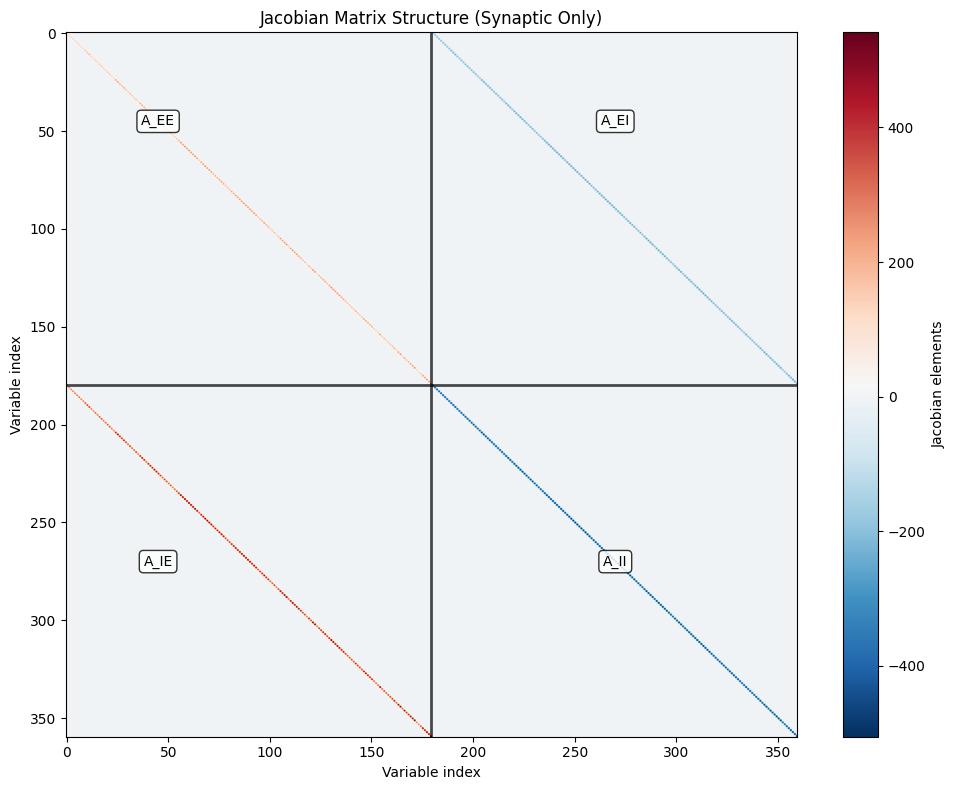

In [9]:
print(eigen_results.keys())
# Optional detailed analysis
analyze_fixed_point(fixed_point)
analyze_eigenspectrum(eigen_results) 
visualize_jacobian(jacobian, heterogeneous.dmf._nc)

Step 2: Stability and Margin 

## New Pipeline Approach

Now we'll switch to the batch processing pipeline that analyzes all particles and saves results to a DataFrame. This implements Step 2 (Stability & Margin) for all particles.


In [25]:
theta_heterogeneous[:,:5].shape

(5, 5)

In [26]:
# Import the new pipeline functions
from picker_utils import analyze_all_particles, analyze_single_particle, analyze_stability_and_margin

# Run the complete pipeline on all particles
# This will analyze all particles and save results to a CSV file
results_df = analyze_all_particles(
    theta_heterogeneous[:,:5], 
    sc, 
    hmap, 
    save_path='particle_analysis_results.csv',
    verbose=True
)

print(f"\nResults DataFrame shape: {results_df.shape}")
print(f"Columns: {list(results_df.columns)}")

Analyzing 5 particles...
Results saved to particle_analysis_results.csv
Analysis complete!
  Successful setups: 0/5
  Particles passing stability (Step 2): 0/5
  Particles passing homotopy (Step 3): 0/5
  Particles passing both steps: 0/5
  Stability regimes: {'error': 5}
  Step failure distribution: {-1: 5}

Results DataFrame shape: (5, 34)
Columns: ['particle_idx', 'G', 'w_EE_bias', 'w_EE_coeff', 'w_EI_bias', 'w_EI_coeff', 'n_regions', 'setup_success', 'lambda_max', 'min_real', 'max_real', 'fraction_complex', 'slowest_timescale', 'passes_leading_stability', 'passes_oscillatory_check', 'passes_stability', 'has_oscillatory_instability', 'stability_regime', 'regime_timescale_range', 'n_complex_eigenvalues', 'epsilon_used', 'error', 'step_failed_at', 'passes_homotopy', 'lambda_max_perturbed', 'perturbations_tested', 'perturbation_pct', 'knob_parameter', 'original_knob_value', 'failed_at_perturbation', 'n_perturbations_tested', 'n_perturbations_failed', 'has_computation_errors', 'computat

In [11]:
# Analyze the results
print("=== PIPELINE RESULTS SUMMARY ===")
print(f"Total particles analyzed: {len(results_df)}")
print(f"Successful setups: {results_df['setup_success'].sum()}")
print(f"Particles passing stability: {results_df['passes_stability'].sum()}")

print(f"\nStability regime distribution:")
print(results_df['stability_regime'].value_counts())

print(f"\nStep failure distribution:")
print(results_df['step_failed_at'].value_counts())

# Filter for good particles
stable_particles = results_df[results_df['passes_stability']]
print(f"\n=== STABLE PARTICLES ({len(stable_particles)}) ===")

if len(stable_particles) > 0:
    print(f"Lambda_max range: [{stable_particles['lambda_max'].min():.4f}, {stable_particles['lambda_max'].max():.4f}]")
    print(f"Slowest timescale range: [{stable_particles['slowest_timescale'].min():.2f}, {stable_particles['slowest_timescale'].max():.2f}] s")
    
    # Show some example particles from different regimes
    print(f"\nExample particles by regime:")
    for regime in stable_particles['stability_regime'].unique():
        regime_particles = stable_particles[stable_particles['stability_regime'] == regime]
        if len(regime_particles) > 0:
            example_idx = regime_particles.iloc[0]['particle_idx']
            lambda_max = regime_particles.iloc[0]['lambda_max']
            tau = regime_particles.iloc[0]['slowest_timescale']
            print(f"  {regime}: particle {example_idx}, λ_max={lambda_max:.4f}, τ={tau:.2f}s")
else:
    print("No stable particles found!")


=== PIPELINE RESULTS SUMMARY ===
Total particles analyzed: 300
Successful setups: 0
Particles passing stability: 0

Stability regime distribution:
stability_regime
error    300
Name: count, dtype: int64

Step failure distribution:
step_failed_at
-1    300
Name: count, dtype: int64

=== STABLE PARTICLES (0) ===
No stable particles found!


## Step 3: Homotopy Check Implementation

Now let's test the new Step 3 (Homotopy/Knife-Edge Check) functionality. This will run the complete pipeline with both Step 2 (Stability) and Step 3 (Homotopy) checks.


In [12]:
# Test Step 3 implementation on a small subset first
import picker_utils
import importlib
importlib.reload(picker_utils)  # Reload to get the latest changes

from picker_utils import analyze_all_particles, run_homotopy_check

# Run analysis on just the first 10 particles to test Step 3
test_particles = theta_heterogeneous

print("Testing Step 3 (Homotopy Check) on first 10 particles...")
print("This will test both Step 2 (Stability) and Step 3 (Homotopy) for each particle.")

results_with_step3 = analyze_all_particles(
    test_particles, 
    sc, 
    hmap, 
    save_path='test_step3_results.csv',
    verbose=True,
    homotopy_knob='G',  # Test perturbations to G parameter
    homotopy_perturbation_pct=10.0  # ±10% perturbations
)

print(f"\nResults with Step 3:")
print(f"Shape: {results_with_step3.shape}")
print(f"New columns from Step 3: {[col for col in results_with_step3.columns if 'homotopy' in col or 'perturbation' in col or 'knob' in col]}")


Testing Step 3 (Homotopy Check) on first 10 particles...
This will test both Step 2 (Stability) and Step 3 (Homotopy) for each particle.
Analyzing 300 particles...
  Progress: 50/300
  Progress: 100/300
  Progress: 150/300
  Progress: 200/300
  Progress: 250/300
  Progress: 300/300
Results saved to test_step3_results.csv
Analysis complete!
  Successful setups: 0/300
  Particles passing stability (Step 2): 0/300
  Particles passing homotopy (Step 3): 0/300
  Particles passing both steps: 0/300
  Stability regimes: {'error': 300}
  Step failure distribution: {-1: 300}

Results with Step 3:
Shape: (300, 34)
New columns from Step 3: ['passes_homotopy', 'perturbations_tested', 'perturbation_pct', 'knob_parameter', 'original_knob_value', 'failed_at_perturbation', 'n_perturbations_tested', 'n_perturbations_failed']


In [13]:
# Analyze the Step 3 results
print("=== STEP 3 ANALYSIS ===")

# Show particles that pass both steps
both_steps = results_with_step3[
    results_with_step3['passes_stability'] & results_with_step3['passes_homotopy']
]
print(f"Particles passing both Step 2 and Step 3: {len(both_steps)}")

# Show breakdown by step failure
step_failures = results_with_step3['step_failed_at'].value_counts().sort_index()
print(f"\nStep failure breakdown:")
for step, count in step_failures.items():
    if step == -1:
        print(f"  Setup errors: {count}")
    elif step == 0:
        print(f"  Pass all steps: {count}")
    elif step == 2:
        print(f"  Fail Step 2 (Stability): {count}")
    elif step == 3:
        print(f"  Fail Step 3 (Homotopy): {count}")

# Show some example homotopy results
print(f"\nExample homotopy check details:")
for i in range(min(3, len(results_with_step3))):
    row = results_with_step3.iloc[i]
    print(f"  Particle {int(row['particle_idx'])}:")
    print(f"    Passes stability: {row['passes_stability']}")
    print(f"    Passes homotopy: {row['passes_homotopy']}")
    if row['passes_stability']:
        print(f"    Homotopy knob: {row['knob_parameter']} = {row['original_knob_value']}")
        print(f"    Perturbation: ±{row['perturbation_pct']}%")
        print(f"    λ_max at perturbations: {row['lambda_max_perturbed']}")
        if row['failed_at_perturbation'] is not None:
            print(f"    Failed at perturbation: {row['failed_at_perturbation']:.3f}")
    print()


=== STEP 3 ANALYSIS ===
Particles passing both Step 2 and Step 3: 0

Step failure breakdown:
  Setup errors: 300

Example homotopy check details:
  Particle 0:
    Passes stability: False
    Passes homotopy: False

  Particle 1:
    Passes stability: False
    Passes homotopy: False

  Particle 2:
    Passes stability: False
    Passes homotopy: False



In [ ]:
# Test the corrected Step 3 implementation
import importlib
importlib.reload(picker_utils)  # Reload with the fixes

from picker_utils import analyze_all_particles

print("Testing CORRECTED Step 3 implementation on first 5 particles...")

# Test with just 5 particles to verify the fix
test_results_corrected = analyze_all_particles(
    theta_heterogeneous[:, :5], 
    sc, 
    hmap, 
    save_path='test_corrected_step3.csv',
    verbose=True,
    homotopy_knob='G',
    homotopy_perturbation_pct=10.0
)

print(f"\n=== CORRECTED RESULTS ===")
print(f"Successful setups: {test_results_corrected['setup_success'].sum()}/5")
print(f"Particles passing stability: {test_results_corrected['passes_stability'].sum()}/5")
print(f"Particles passing homotopy: {test_results_corrected['passes_homotopy'].sum()}/5")
print(f"Step failure distribution: {test_results_corrected['step_failed_at'].value_counts().to_dict()}")
